In [1]:
import requests
from urllib.robotparser import RobotFileParser

BASE_URL = "https://remoteok.com"
SCRAPE_URL = "https://remoteok.com/remote-dev-jobs"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36"
}


response = requests.get(f"{BASE_URL}/robots.txt", headers=headers)
print(response.text)

User-agent: *
Crawl-delay: 1
Allow: /
Sitemap: https://remoteok.com/sitemap.xml

User-agent: AhrefsBot
Disallow: /


Disallow: /*?action=get_jobs
Disallow: /*?*action=get_jobs
Disallow: /*?*&action=get_jobs
Disallow: /*?*&action=get_jobs&*


User-agent: SemrushBot
Disallow: /

User-agent: SemrushBot-BA
Disallow: /

# Majestic - SEO
User-agent: MJ12bot
Disallow: /

User-agent: Screaming Frog SEO Spider
Disallow: /

# Seozoom - SEO
User-Agent: ZoomBot
Disallow: /

User-agent: sistrix
Disallow: /

User-agent: serpstatbot
Disallow: /

User-agent: MozBot
Disallow: /

# https://moz.com/help/moz-procedures/crawlers/rogerbot
User-agent: rogerbot
Disallow: /

# https://moz.com/help/moz-procedures/crawlers/dotbot
User-agent: dotbot
Disallow: /

User-agent: DataForSeoBot
Disallow: /

Disallow: /l/
Disallow: /*ou-tout-autre*
Disallow: /*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*



In [2]:
import requests
import time

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36"
}

url = "https://remoteok.com/api"

response = requests.get(url, headers=headers)
time.sleep(1)

data = response.json()

print(f"NO OF OBJECTS: {len(data)}")

print(data[1])  

NO OF OBJECTS: 99
{'slug': 'remote-accountant-hologram-1130647', 'id': '1130647', 'epoch': 1772740807, 'date': '2026-03-05T20:00:07+00:00', 'company': 'Hologram', 'company_logo': '', 'position': 'Accountant', 'tags': ['accountant', 'saas', 'manager', 'accounting', 'financial', 'go'], 'description': "<div>\n<p>&nbsp;</p>\n<h1><strong>About Hologram</strong></h1>\n<p>Hologram is building the future of IoT connectivity, delivering internet access to millions of connected devices worldwide. We process&nbsp;<strong>over 5 billion transactions per month</strong>&nbsp;across our global infrastructureâ\x80\x94this isn't just another app, it's the invisible backbone powering everything from fleet tracking to smart city infrastructure. We tackle challenges of scale, reliability, and performance that few companies face.</p>\n<h2><strong>What Makes a Hologrammer?</strong></h2>\n<p>We look for people with insatiable curiosity and an uncompromising commitment to excellence. Hologrammers are the type

In [3]:
data[1].keys()

dict_keys(['slug', 'id', 'epoch', 'date', 'company', 'company_logo', 'position', 'tags', 'description', 'location', 'apply_url', 'salary_min', 'salary_max', 'logo', 'url'])

In [4]:
import pandas as pd


jobs = data[1:]
df = pd.DataFrame(jobs)

df = df[["position", "company", "location", "tags", "date"]]


print(df.head())
print(f"{df.shape}")

                         position                   company     location  \
0                      Accountant                  Hologram                
1                Staff Accountant                 1upHealth  Remote - US   
2  Senior Software Engineer React            Creative Chaos                
3          Mandarin Interpreter S  Two95 International Inc.                
4          Communications Manager                    CertiK  US / Remote   

                                                tags  \
0  [accountant, saas, manager, accounting, financ...   
1  [accountant, support, accounting, payroll, fin...   
2  [react, software, design, jira, front-end, bac...   
3                                     [ios, support]   
4  [manager, web3, security, technical, support, ...   

                        date  
0  2026-03-05T20:00:07+00:00  
1  2026-03-05T19:00:05+00:00  
2  2026-03-05T16:00:14+00:00  
3  2026-03-05T16:00:07+00:00  
4  2026-03-05T15:00:04+00:00  
(98, 5)


In [5]:
df

,position,company,location,tags,date
0,Accountant,Hologram,,"[accountant, saas, manager, accounting, financ...",2026-03-05T20:00:07+00:00
1,Staff Accountant,1upHealth,Remote - US,"[accountant, support, accounting, payroll, fin...",2026-03-05T19:00:05+00:00
2,Senior Software Engineer React,Creative Chaos,,"[react, software, design, jira, front-end, bac...",2026-03-05T16:00:14+00:00
3,Mandarin Interpreter S,Two95 International Inc.,,"[ios, support]",2026-03-05T16:00:07+00:00
4,Communications Manager,CertiK,US / Remote,"[manager, web3, security, technical, support, ...",2026-03-05T15:00:04+00:00
...,...,...,...,...,...
93,Senior Solutions Engineer North East,"Okta, Inc.",,"[security, senior, engineer]",2026-02-22T16:00:04+00:00
94,Product Manager Customer Care,RYZ Labs,Buenos Aires,"[manager, salesforce, support, strategy, manag...",2026-02-22T00:00:04+00:00
95,,,,"[growth, management, sales]",2026-02-21T21:00:02+00:00
96,Nurse Practitioner Physician Assistant,Ennoble Care,"Trenton, New Jersey","[assistant, consult, testing, mobile, operatio...",2026-02-21T16:00:09+00:00


In [6]:
df['date'] = pd.to_datetime(df['date']).dt.date

In [7]:
df['location']=df['location'].replace('','Remote')
df['location']=df['location'].fillna('Remote')

In [8]:
df.head()

,position,company,location,tags,date
0,Accountant,Hologram,Remote,"[accountant, saas, manager, accounting, financ...",2026-03-05
1,Staff Accountant,1upHealth,Remote - US,"[accountant, support, accounting, payroll, fin...",2026-03-05
2,Senior Software Engineer React,Creative Chaos,Remote,"[react, software, design, jira, front-end, bac...",2026-03-05
3,Mandarin Interpreter S,Two95 International Inc.,Remote,"[ios, support]",2026-03-05
4,Communications Manager,CertiK,US / Remote,"[manager, web3, security, technical, support, ...",2026-03-05


In [9]:
all_tags = df['tags'].explode()
skill_counts = all_tags.value_counts()
print(skill_counts.head(10))

tags
senior         37
engineer       28
technical      28
support        26
growth         23
manager        22
lead           22
engineering    21
management     17
sales          17
Name: count, dtype: int64


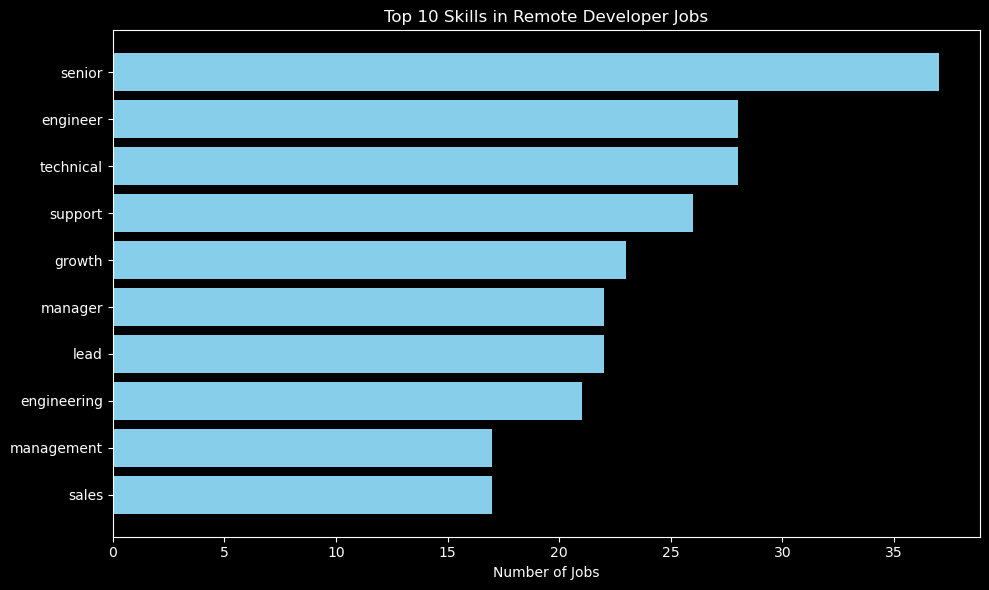

In [10]:
import matplotlib.pyplot as plt
top_skills = skill_counts.head(10)
plt.style.use("dark_background")
plt.figure(figsize=(10, 6))
plt.barh(top_skills.index, top_skills.values, color='skyblue')
plt.xlabel('Number of Jobs')
plt.title('Top 10 Skills in Remote Developer Jobs')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

In [11]:
city_jobs=df[df['location']!="Remote"].copy()
print(f" City Jobs number : {len(city_jobs)}")
print(city_jobs["location"].unique())

 City Jobs number : 45
['Remote - US' 'US / Remote' 'Georgia; Singapore; Sri Lanka; Uzbekistan'
 'Finland' 'United States - East Coast' 'Seattle, Washington'
 'United States' 'Reston, VA' 'Bellevue' 'Singapore' 'Warsaw'
 'Germany - Remote; United Kingdom - Remote' 'Slovakia'
 'San Francisco, CA' 'Denver, CO - Remote'
 'Boulder/Denver, New York City, or Boston' 'U. S.'
 'United States (Remote)' 'Remote - Santo Domingo' 'Dallas, TX' 'BC'
 'Mexico City' 'India' 'United Kingdom' 'Asia' 'Turkey' 'Culver City'
 'Anywhere' 'Any city' 'DC or NYC' 'Long Beach, California' 'Bozeman'
 'Toronto' 'Ogema,MN' 'Buenos Aires' 'Trenton, New Jersey']


In [12]:
exclude = ["Anywhere", "Any city", "Remote", "United States", 
           "U. S.", "USA", "United States (Remote)", "Asia"]
city_jobs = city_jobs[~city_jobs['location'].isin(exclude)]

city_jobs = city_jobs.assign(location=city_jobs["location"].str.split(";")).explode("location")

city_jobs["location"] = city_jobs["location"].str.strip()

print(f" City Jobs number after filtering : {len(city_jobs)}")
print(city_jobs["location"].unique())


 City Jobs number after filtering : 36
['Remote - US' 'US / Remote' 'Georgia' 'Singapore' 'Sri Lanka'
 'Uzbekistan' 'Finland' 'United States - East Coast' 'Seattle, Washington'
 'Reston, VA' 'Bellevue' 'Warsaw' 'Germany - Remote'
 'United Kingdom - Remote' 'Slovakia' 'San Francisco, CA'
 'Denver, CO - Remote' 'Boulder/Denver, New York City, or Boston'
 'Remote - Santo Domingo' 'Dallas, TX' 'BC' 'Mexico City' 'India'
 'United Kingdom' 'Turkey' 'Culver City' 'DC or NYC'
 'Long Beach, California' 'Bozeman' 'Toronto' 'Ogema,MN' 'Buenos Aires'
 'Trenton, New Jersey']


In [13]:

city_jobs = city_jobs[~city_jobs["location"].str.contains(
    "Remote|or |/|East Coast|BC|DC|Ogema", case=False
)]


city_jobs["location"] = city_jobs["location"].str.split(",").str[0].str.strip()

print(f"City Jobs number after filtering: {len(city_jobs)}")
print(city_jobs["location"].unique())

City Jobs number after filtering: 25
['Georgia' 'Singapore' 'Sri Lanka' 'Uzbekistan' 'Finland' 'Seattle'
 'Reston' 'Bellevue' 'Warsaw' 'Slovakia' 'San Francisco' 'Dallas'
 'Mexico City' 'India' 'United Kingdom' 'Turkey' 'Culver City'
 'Long Beach' 'Bozeman' 'Toronto' 'Buenos Aires' 'Trenton']


In [14]:
city_jobs

,position,company,location,tags,date
8,DevOps Engineer,MEMX,Georgia,"[system, security, software, devops, operation...",2026-03-04
8,DevOps Engineer,MEMX,Singapore,"[system, security, software, devops, operation...",2026-03-04
8,DevOps Engineer,MEMX,Sri Lanka,"[system, security, software, devops, operation...",2026-03-04
8,DevOps Engineer,MEMX,Uzbekistan,"[system, security, software, devops, operation...",2026-03-04
9,Lab Technician,ICEYE,Finland,[],2026-03-04
16,Senior Open Source Intelligence Analyst,Concentric Advisors,Seattle,"[analyst, embedded, security, training, consul...",2026-03-04
22,Cloud Architect,Accenture Federal Services,Reston,"[architect, design, security, training, techni...",2026-03-03
23,Contract Senior Gameplay Animator,ArenaNet,Bellevue,"[design, game, technical, developer, animator,...",2026-03-03
24,AI Data Specialist Chinese Simplified,RWS TrainAI,Singapore,"[support, content]",2026-03-03
25,AI Data Specialist Polish,RWS TrainAI,Warsaw,"[support, content]",2026-03-03


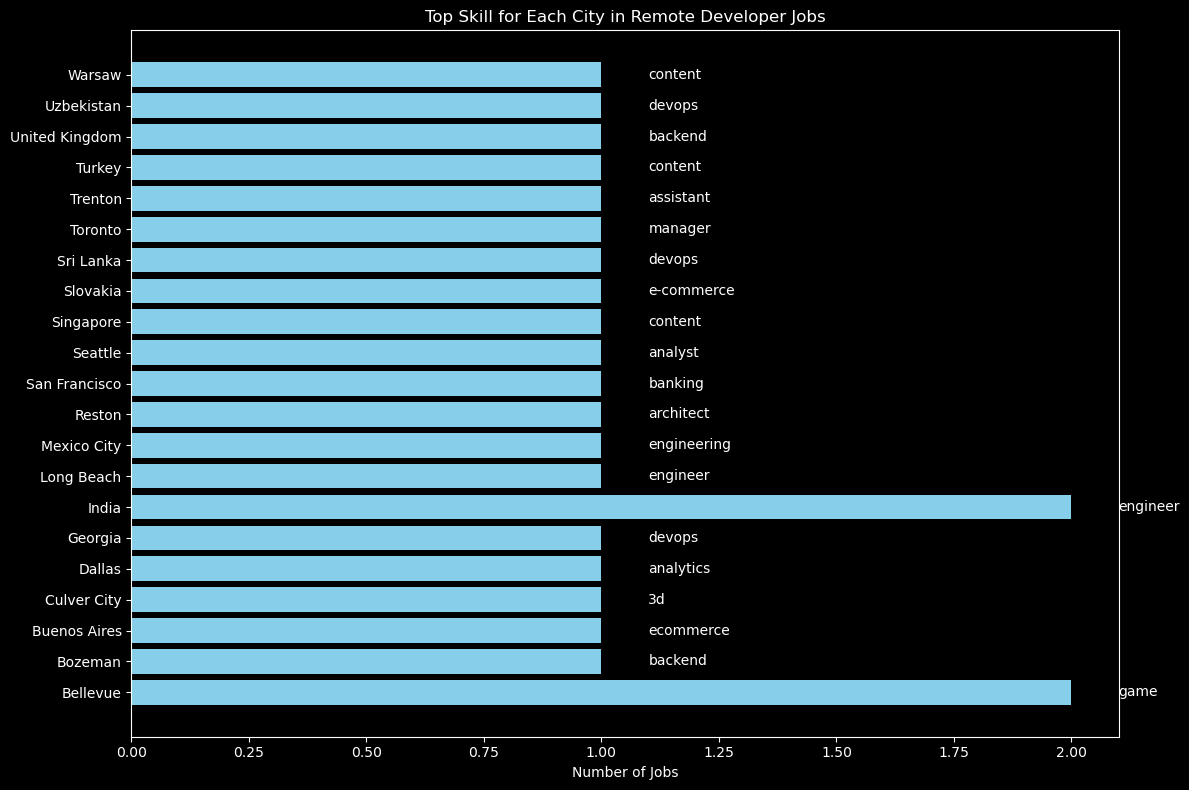

In [15]:
city_skills = city_jobs.explode("tags")
city_skills_counts = city_skills.groupby(["location", "tags"]).size().reset_index(name="count")
top_city_skills = city_skills_counts.loc[city_skills_counts.groupby("location")["count"].idxmax()]


plt.figure(figsize=(12, 8))
plt.barh(top_city_skills["location"], top_city_skills["count"], color='skyblue')
for i, (skill, count) in enumerate(zip(top_city_skills["tags"], top_city_skills["count"])):
    plt.text(count + 0.1, i, skill, va="center", color="white")
plt.xlabel('Number of Jobs')
plt.title('Top Skill for Each City in Remote Developer Jobs')

plt.tight_layout()
plt.show()



In [16]:

role_tags = ["engineer", "manager", "developer", "analyst", 
             "designer", "director", "scientist", "architect", 
             "lead", "consultant"]

all_tags_series = df["tags"].explode()
role_counts = all_tags_series[all_tags_series.isin(role_tags)].value_counts()

print(role_counts)

tags
engineer     28
manager      22
lead         22
designer      6
director      5
analyst       4
architect     2
developer     2
Name: count, dtype: int64


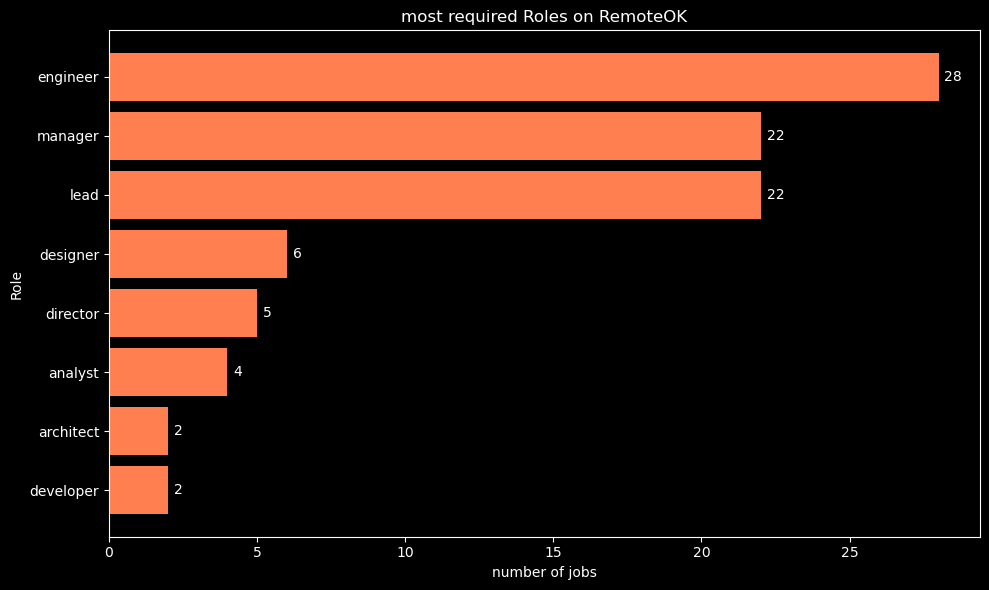

In [17]:

plt.figure(figsize=(10, 6))
plt.barh(role_counts.index, role_counts.values, color="coral")

for i, (role, count) in enumerate(zip(role_counts.index, role_counts.values)):
    plt.text(count + 0.2, i, str(count), va="center", color="white")

plt.xlabel("number of jobs")
plt.ylabel("Role")
plt.title("most required Roles on RemoteOK")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()